# Portfolio Lab — EUR investor study

Run top to bottom after package installation. All calculations and safeguards live in portfolio_lab. No prices or FX are forward-filled.

In [1]:
from dataclasses import replace
from pathlib import Path
from IPython.display import display, Image
from portfolio_lab.config import load_config, configure_universe
from portfolio_lab.data import load_market_data, study_coverage
from portfolio_lab.leverage import add_leverage
from portfolio_lab.metrics import compute_asset_metrics
from portfolio_lab.optimization import optimize_frontier
from portfolio_lab.plotting import plot_frontier, plot_drawdown, allocation_summary
from portfolio_lab.reporting import format_weights, write_review_outputs

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


## User configuration
Select display names, registered tickers and leverage below. Financial metadata lives in `src/portfolio_lab/assets.py`. Run All after every change.

In [2]:
assets = {
    "Apple": "AAPL",
    "Nasdaq 100": "QQQ",
    "S&P 500": "^SP500TR",
    "Dow Jones": "DIA",
    "CAC 40": "PX1GR.PA",
    "Gold": "GC=F",
    "Obligation": "IBGS.AS",
}

leveraged_assets = {
    "Apple": 1.0,
    "Nasdaq 100": 1.0,
}

config = configure_universe(load_config(project_dir), assets, leveraged_assets)
# Optional study overrides:
# config = replace(config, risk_free_rate=0.02, frontier_points=75)


## Market data and provenance

Adjusted equity prices are a reinvestment proxy. Gross-return indices incorporate gross dividends. Gold futures quotations are not an investable total-return benchmark.

In [3]:
data = load_market_data(config)
display(data.provenance)
display(data.fx_sample)
display(study_coverage(data, config))


c:\Users\tminot\Documents\Scripts Python\Mes Scripts\portfolio-optimization\.venv\Lib\site-packages\yfinance\utils.py:612: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  last_rows_same_interval = (dt2 - dt1) < _pd.Timedelta(interval)


,Provider,Symbol,Instrument / benchmark,Return type,Native currency,Converted to,FX series used,Raw start date,Raw end date,Raw observations,Raw missing observations,FX missing on observed sessions,EUR observations,Final common start,Final common end,Final common observations,Distributions,Limitation,Reference
Asset,,,,,,,,,,,,,,,,,,,
Apple,Yahoo Finance,AAPL,Primary US equity,Adjusted price,USD,EUR,EURUSD=X,1980-12-12,2026-10-02,11544,0,5828,5716,2008-01-02,2015-12-18,1964,Yahoo split/dividend adjustment; reinvestment ...,"Adjusted prices are a vendor proxy, not an ind...",
Nasdaq 100,Yahoo Finance,QQQ,Invesco QQQ ETF; Nasdaq-100 exposure proxy,Adjusted price,USD,EUR,EURUSD=X,1999-03-10,2026-10-02,6935,0,1219,5716,2008-01-02,2015-12-18,1964,Yahoo dividend/split adjustments; distribution...,Exact Nasdaq-100 TR unavailable from tested Ya...,https://www.invesco.com/qqq-etf/en/home.html
S&P 500,Yahoo Finance,^SP500TR,S&P 500 Total Return index,Gross Return,USD,EUR,EURUSD=X,1988-01-04,2026-10-02,9761,0,4045,5716,2008-01-02,2015-12-18,1964,Gross dividends reinvested by index methodology,,https://www.spglobal.com/spdji/en/indices/equi...
Dow Jones,Yahoo Finance,DIA,State Street SPDR Dow Jones Industrial Average...,Adjusted price,USD,EUR,EURUSD=X,1998-01-20,2026-10-02,7221,0,1505,5716,2008-01-02,2015-12-18,1964,Yahoo dividend/split adjustments; distribution...,Exact Dow Jones TR unavailable from tested Yah...,https://www.ssga.com/us/en/individual/etfs/sta...
CAC 40,Yahoo Finance,PX1GR.PA,CAC 40 Gross Return Index,Gross Return,EUR,EUR,None,1987-12-31,2015-12-18,7076,2930,0,7076,2008-01-02,2015-12-18,1964,Gross dividends reinvested in index levels; no...,Yahoo daily history has missing observations; ...,https://live.euronext.com/en/product/indices/Q...
Gold,Yahoo Finance,GC=F,Yahoo continuous COMEX gold futures quotation,Price Return,USD,EUR,EURUSD=X,2000-08-30,2026-10-02,6548,83,840,5708,2008-01-02,2015-12-18,1964,No dividends; quoted futures price changes only,Not spot gold or an investable futures total-r...,
Obligation,Yahoo Finance,IBGS.AS,iShares € Govt Bond 1-3yr UCITS ETF; Euronext ...,Adjusted price,EUR,EUR,None,2008-01-02,2026-10-02,4799,1,0,4799,2008-01-02,2015-12-18,1964,Yahoo dividend/split adjustments; distribution...,ETF fees and tracking differences apply.,https://finance.yahoo.com/quote/IBGS.AS/


,USD value,EURUSD,Computed EUR value
Date,,,
2008-01-02,5.827591,1.471692,3.959790
2008-01-03,5.830284,1.474491,3.954099
2008-01-04,5.385229,1.475492,3.649785
2008-01-07,5.313148,1.468299,3.618573
2008-01-08,5.122025,1.557099,3.289467


{'common_start': '2008-01-02',
 'common_end': '2015-12-18',
 'common_observations': 1964,
 'latest_raw_asset_start': '2008-01-02',
 'raw_start_limiting_assets': ['Obligation'],
 'earliest_raw_asset_end': '2015-12-18',
 'raw_end_limiting_assets': ['CAC 40'],
 'latest_eur_asset_start': '2008-01-02',
 'eur_start_limiting_assets': ['Obligation'],
 'start_limiting_series': ['Obligation'],
 'fx_start': '2003-12-01',
 'first_common_date_delayed_by_calendar': False}

## Daily-reset synthetic assets

Reset on every native underlying session, then translate NAV into EUR with unlevered FX. Compound before sampling common dates.

In [4]:
prices, leverage_diagnostics = add_leverage(data.common, data.native, data.fx, config)
display(leverage_diagnostics)

,Asset,Underlying,Leverage,Reset sessions,Worst underlying return,Wipeout date
0,Apple x1,Apple,1.0,2007,-0.179195,NaT
1,Nasdaq 100 x1,Nasdaq 100,1.0,2007,-0.089557,NaT


## Asset performance in EUR

In [5]:
stats = compute_asset_metrics(prices, config.trading_days, config.risk_free_rate, config.calendar_days_per_year)
display(stats)

,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple x1,0.240334,0.285109,0.360239,-0.546559,0.791445,0.439723
Apple,0.240334,0.285109,0.360239,-0.546559,0.791445,0.439723
Obligation,0.015302,0.015781,0.022932,-0.039391,0.688146,0.388477
Nasdaq 100,0.157068,0.182727,0.259534,-0.411399,0.704059,0.381789
Nasdaq 100 x1,0.157068,0.182727,0.259534,-0.411399,0.704059,0.381789
Dow Jones,0.102489,0.128086,0.238147,-0.395717,0.537845,0.258995
S&P 500,0.106464,0.134352,0.248635,-0.438416,0.540359,0.242838
Gold,0.068026,0.094625,0.234265,-0.373896,0.403924,0.181939
CAC 40,0.015422,0.048819,0.257939,-0.527281,0.189264,0.029247


## Growth frontier and volatility ceilings

Constant weights, long-only; rebalance at each common observation. Leveraged versions replace their underlying in the configured universe.

In [6]:
optimization = optimize_frontier(prices, config)
display(optimization.summary)
display(format_weights(optimization.weights))
display(allocation_summary(optimization.weights, config.allocation_display_threshold))
display(optimization.dominance)

,CAGR,Mean return annualized,Volatility,Max Drawdown,Sharpe,Calmar,Success,Solver status,Status,Risk ceiling
Portfolio,,,,,,,,,,
Minimum Volatility,0.016975,0.017459,0.022795,-0.035441,0.765917,0.478957,True,0,Optimization terminated successfully,NaN
Maximum CAGR,0.240334,0.285109,0.360239,-0.546559,0.791445,0.439723,True,0,Optimization terminated successfully,NaN
Maximum Sharpe,0.034713,0.035393,0.032401,-0.039187,1.092333,0.885845,True,0,Optimization terminated successfully,NaN
Prudent,0.126029,0.13253,0.15,-0.229909,0.883534,0.548171,True,0,Optimization terminated successfully,0.15
Modéré,0.16001,0.171649,0.2,-0.301531,0.858243,0.530657,True,0,Optimization terminated successfully,0.2
Dynamique,0.21879,0.247186,0.3,-0.45222,0.823952,0.483813,True,0,Optimization terminated successfully,0.3
Agressif,0.240334,0.285109,0.360239,-0.546559,0.791445,0.439723,True,0,Maximum CAGR reached; unused risk allowance,0.4
Très agressif,0.240334,0.285109,0.360239,-0.546559,0.791445,0.439723,True,0,Maximum CAGR reached; unused risk allowance,0.5


,Apple x1,Nasdaq 100 x1,S&P 500,Dow Jones,CAC 40,Gold,Obligation
Portfolio,,,,,,,
Minimum Volatility,0.37%,0.00%,0.26%,0.00%,0.30%,0.34%,98.73%
Maximum CAGR,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Maximum Sharpe,5.70%,1.19%,0.00%,0.00%,0.00%,2.89%,90.22%
Prudent,34.06%,6.99%,0.00%,0.00%,0.00%,16.92%,42.03%
Modéré,45.46%,9.35%,0.00%,0.00%,0.00%,22.59%,22.59%
Dynamique,80.09%,0.00%,0.00%,0.00%,0.00%,19.91%,0.00%
Agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Très agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


Portfolio
Minimum Volatility                                     Obligation 98.7%
Maximum CAGR                                            Apple x1 100.0%
Maximum Sharpe        Obligation 90.2% · Apple x1 5.7% · Gold 2.9% ·...
Prudent               Obligation 42.0% · Apple x1 34.1% · Gold 16.9%...
Modéré                Apple x1 45.5% · Gold 22.6% · Obligation 22.6%...
Dynamique                                   Apple x1 80.1% · Gold 19.9%
Agressif                                                Apple x1 100.0%
Très agressif                                           Apple x1 100.0%
dtype: object

,100% CAGR,100% volatility,Frontier CAGR,Frontier volatility
Asset,,,,
Apple x1,0.240334,0.360239,0.240334,0.360239
Nasdaq 100 x1,0.157068,0.259534,0.197783,0.259534
S&P 500,0.106464,0.248635,0.191098,0.248635
Dow Jones,0.102489,0.238147,0.184563,0.238147
CAC 40,0.015422,0.257939,0.196814,0.257939
Gold,0.068026,0.234265,0.182121,0.234265
Obligation,0.015302,0.022932,0.018917,0.022932


## Charts

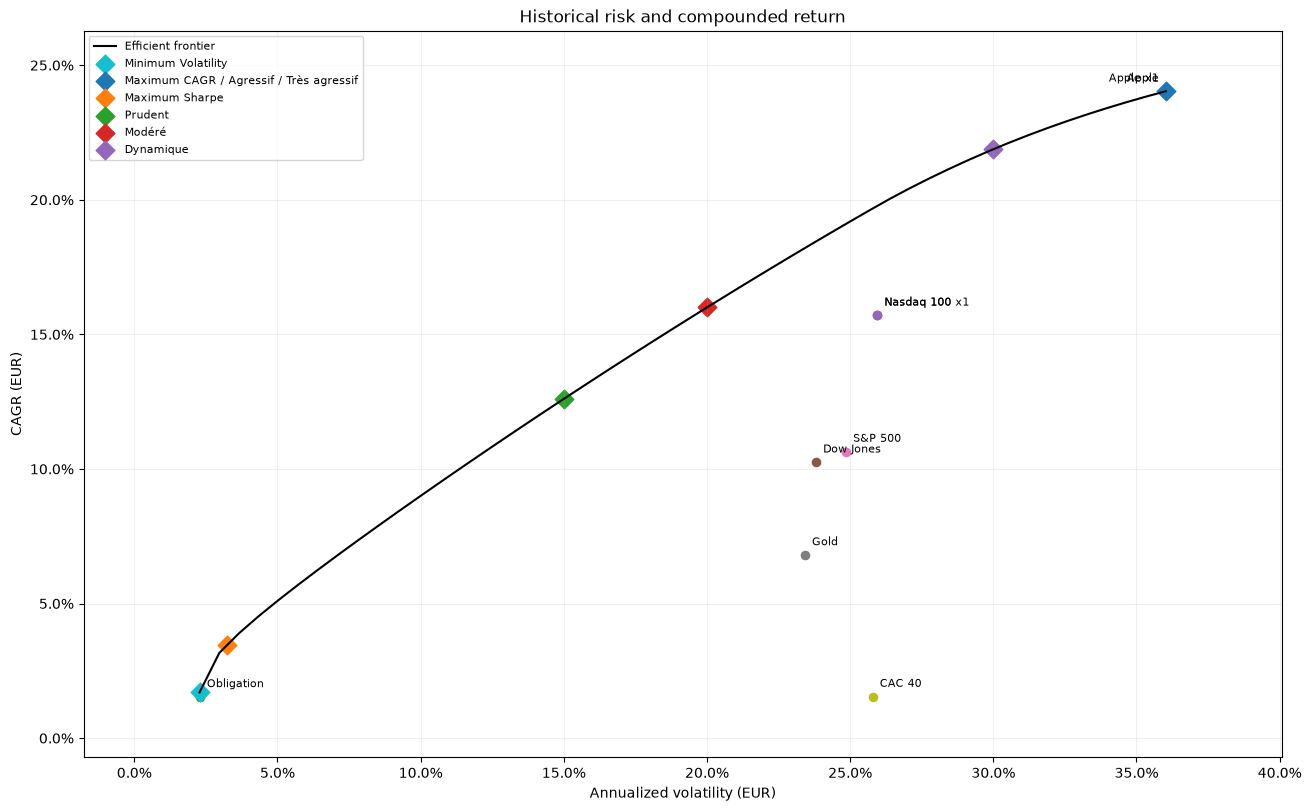

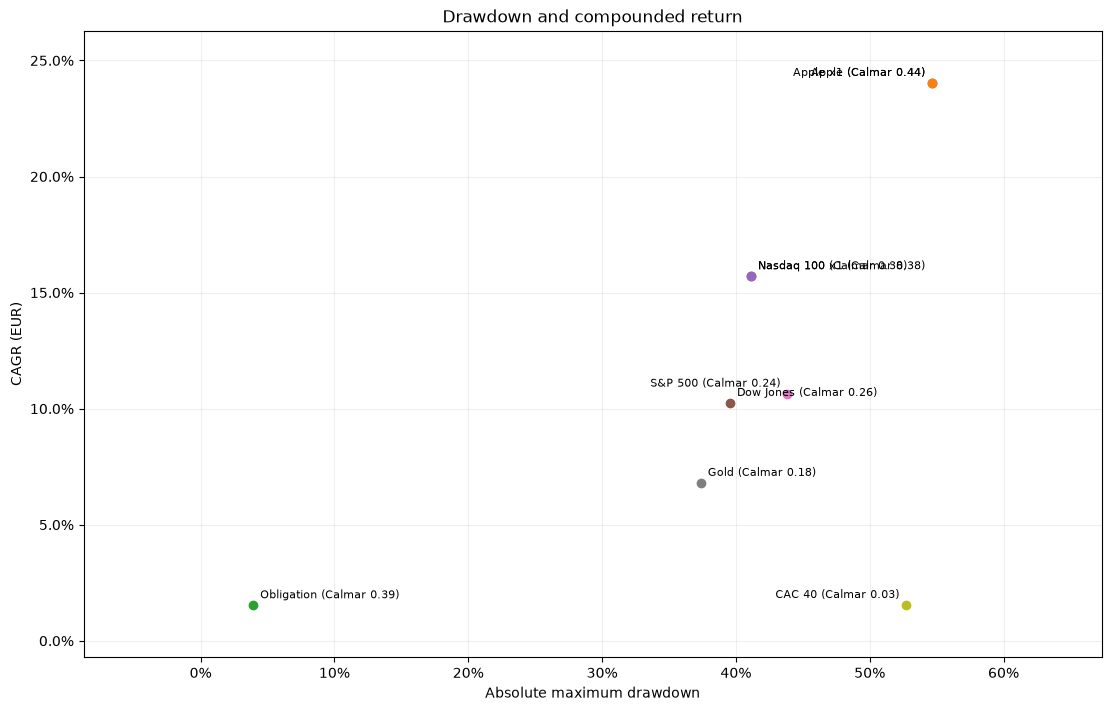

In [7]:
frontier_figure = plot_frontier(stats, optimization)
drawdown_figure = plot_drawdown(stats)

## Export evidence and validate numerical results

{'portfolio_weight_sums': {'Minimum Volatility': 1.0,
  'Maximum CAGR': 0.9999999999999999,
  'Maximum Sharpe': 1.0,
  'Prudent': 1.0,
  'Modéré': 1.0,
  'Dynamique': 0.9999999999999999,
  'Agressif': 0.9999999999999999,
  'Très agressif': 0.9999999999999999,
  'Frontier 0': 1.0,
  'Frontier 1': 1.0,
  'Frontier 2': 1.0,
  'Frontier 3': 1.0,
  'Frontier 4': 1.0,
  'Frontier 5': 1.0,
  'Frontier 6': 1.0,
  'Frontier 7': 1.0,
  'Frontier 8': 1.0,
  'Frontier 9': 1.0,
  'Frontier 10': 1.0,
  'Frontier 11': 1.0,
  'Frontier 12': 1.0,
  'Frontier 13': 1.0,
  'Frontier 14': 1.0,
  'Frontier 15': 1.0,
  'Frontier 16': 1.0,
  'Frontier 17': 1.0,
  'Frontier 18': 1.0,
  'Frontier 19': 1.0,
  'Frontier 20': 1.0,
  'Frontier 21': 1.0,
  'Frontier 22': 1.0,
  'Frontier 23': 1.0,
  'Frontier 24': 1.0,
  'Frontier 25': 1.0,
  'Frontier 26': 1.0,
  'Frontier 27': 1.0000000000000002,
  'Frontier 28': 1.0,
  'Frontier 29': 1.0000000000000002,
  'Frontier 30': 1.0,
  'Frontier 31': 1.0,
  'Frontier 32':

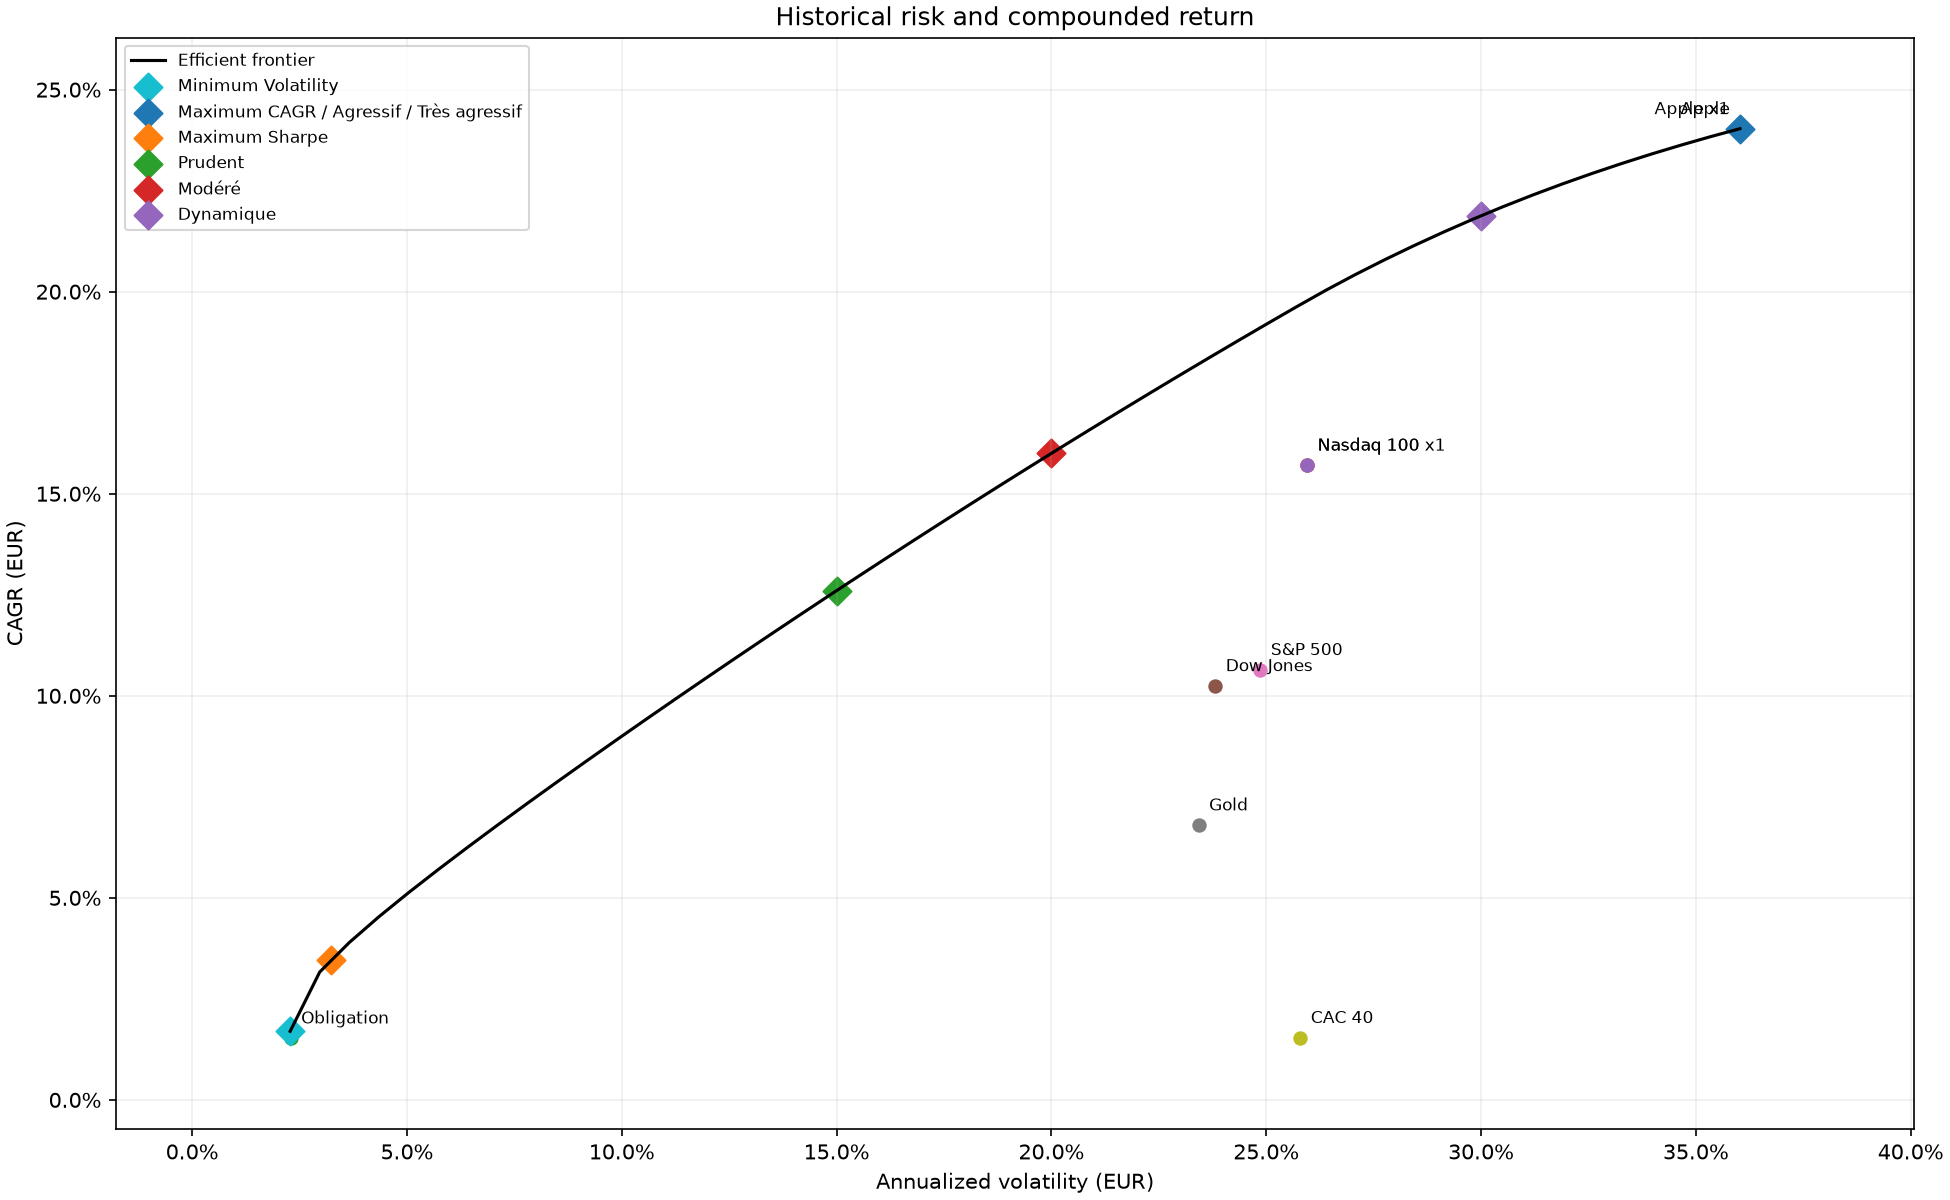

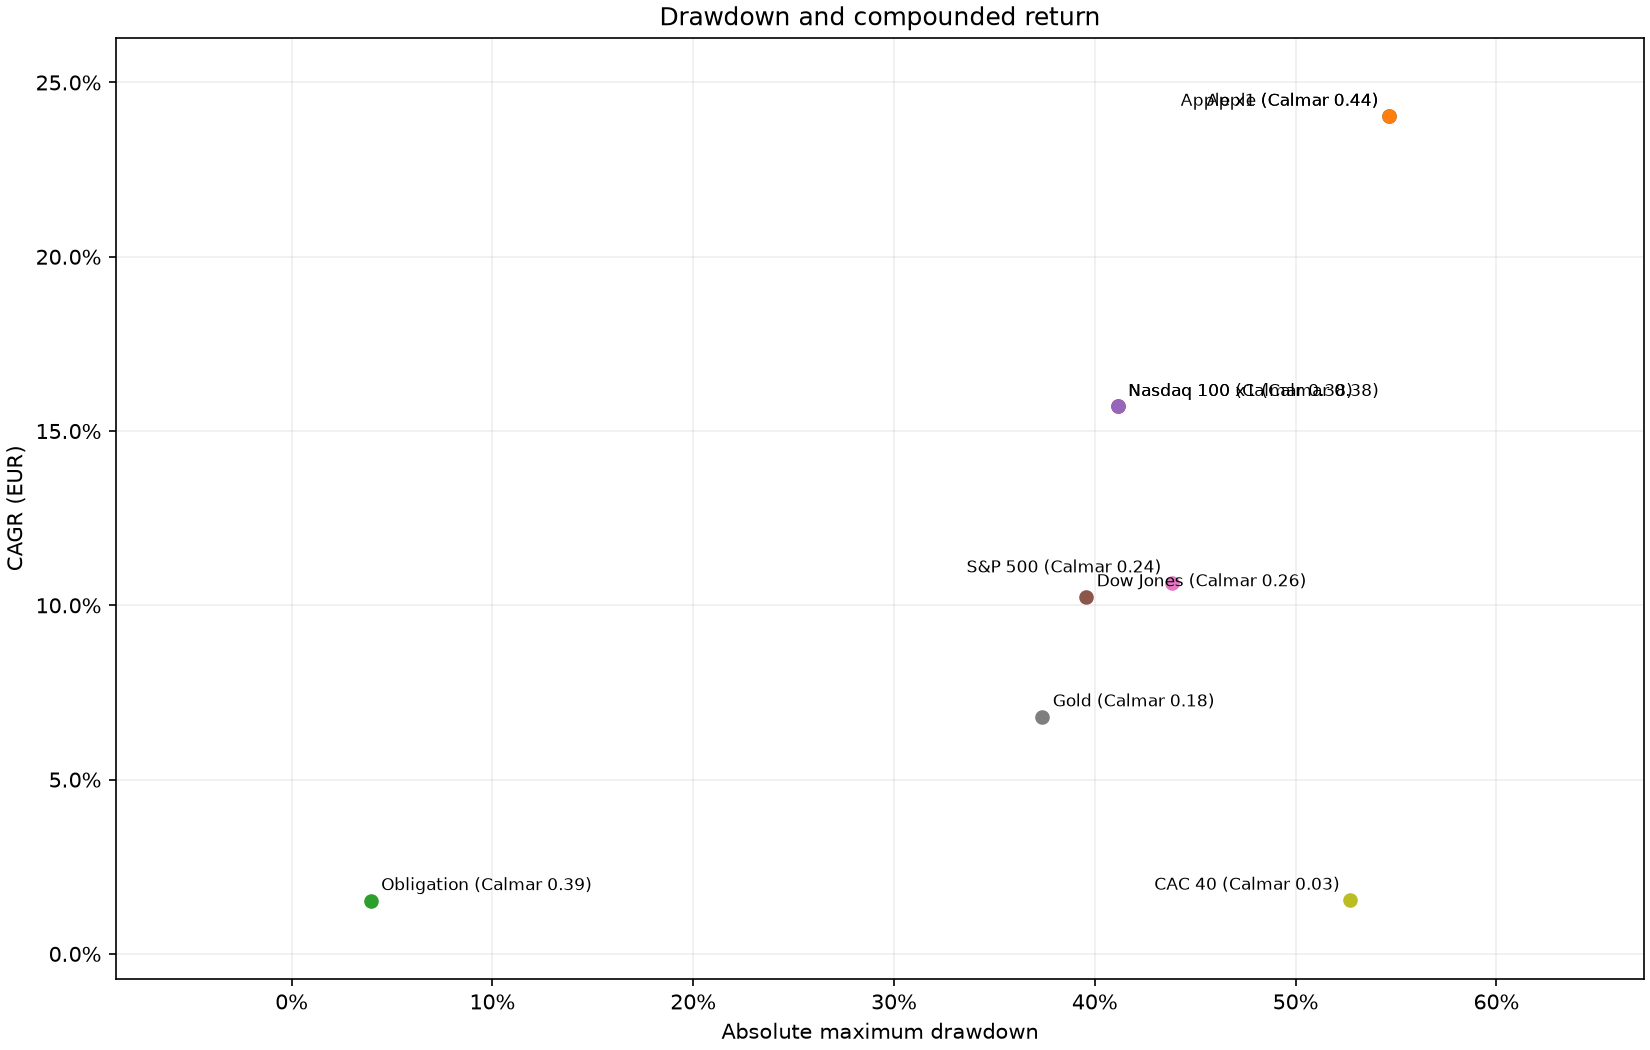

In [8]:
sanity = write_review_outputs(data, prices, stats, leverage_diagnostics, optimization, config)
frontier_figure.savefig(config.output_dir / "frontier.png", dpi=150)
drawdown_figure.savefig(config.output_dir / "drawdown.png", dpi=150)
display(sanity)
display(Image(filename=str(config.output_dir / "frontier.png")))
display(Image(filename=str(config.output_dir / "drawdown.png")))
